# Physical-level QUOPS in guppy

## Introduction

This notebook outlines how to use runtime randomness in guppy to execute the QUOPS benchmark in a sample-efficient manner. An introduction to runtime randomness in Guppy can also be found in the [guppy docs](https://docs.quantinuum.com/guppy/language_guide/random.html) (see also [the RNG notebook](https://docs.quantinuum.com/guppy/guppylang/examples/random_numbers.html)).

In this notebook we use guppy `v1`. See [the docs](https://docs.quantinuum.com/guppy/) for a more thorough overview of Guppy and its features.

# Table of Contents
* [QUOPS circuits](#circuits)
* [MCFE basics](#mcfe)
    * [Pauli twirling](#rc)
    * [Randomized state preparation](#spam)
    * [Putting everything together](#combining)
    * [Sanity checks](#checks)
* [Statistics](#stats)

## QUOPS circuits <a class="anchor" id="circuits"></a>

QUOPS circuits are random circuits consisting of dense layers of gates, alternating between layers of single-qubit (1Q) Pauli rotations and randomly paired two-qubit (2Q) CNOT gates. QUOPS circuits are parametrized by their width (the number of qubits they act on), and their size (the number of 1Q gates they contain, plus twice the number of 2Q gates). However, in the following, we choose to parameterize them instead by their width and a (fractional) depth. 

<div class="alert alert-block alert-warning">

In this notebook, depth refers to the number of benchmarking layers in the circuit. This differs from the paper's definition (equal to the total number of layers), which is twice as large as the one used here.

</div>

When the depth is an integer, QUOPS circuits consist of dense double layers. In the layer of 1Q Pauli rotations $R_P(\theta)$, each $R_P(\theta)$ involves a randomly chosen rotation angle $\theta \in [0, 2\pi)$ and a randomly chosen Pauli axis $P \in \{X, Y, Z\}$. These angles and axes are chosen independently for every qubit and furthermore every layer is independent. In the CNOT layer, CNOT gates act between every pair of qubits for a pairing of qubits chosen uniformly at random (leaving out one qubit if the width is odd). Again, the random pairing is chosen independently in every layer. A random pairing of the qubits is illustrated below:


In [ ]:
import numpy as np
from typing import no_type_check

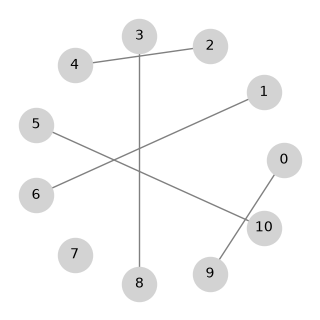

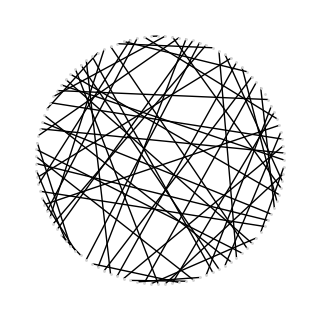

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random


def draw_random_pairing(n: int, **kwargs):
    graph = nx.Graph()
    graph.add_nodes_from(range(n))

    # Create a random pairing of nodes
    nodes = list(range(n))
    random.shuffle(nodes)
    edges = [(nodes[i], nodes[i + 1]) for i in range(0, n - 1, 2)]

    graph.add_edges_from(edges)
    pos = nx.circular_layout(graph)

    plt.figure(figsize=(3, 3))
    nx.draw(
        graph,
        pos,
        **kwargs,
    )


draw_random_pairing(
    11,
    with_labels=True,
    node_color="lightgray",
    edge_color="gray",
    node_size=600,
    font_size=10,
    width=1.0,
)
draw_random_pairing(111, node_size=1, node_color="lightgray")

When the depth is *not* an integer, the final layer acts on a randomly chosen subset of qubits. The number of 1Q and 2Q gates in such circuits with fractional depths can be found using the following helper functions:

In [ ]:
def final_layer_qubits(width: int, depth: int | float) -> int:
    """Return the number of qubits that belong to the final layer.

    Extracts the final layer filling fraction and finds nearest integer
    number of qubits. If depth is an integer, returns 0.
    """
    bulk_depth = int(depth)
    final_layer_fraction = round((depth - bulk_depth) * width)

    return final_layer_fraction


def count_1q_gates(width: int, depth: int | float) -> int:
    """Return the number of 1Q gates in a QUOPS circuit specified by width and depth.

    Every layer contains a number of 1Q gates equal to the number of qubits that it acts on.
    """
    bulk_depth = int(depth)
    bulk_1q_gates = width * bulk_depth
    final_1q_gates = final_layer_qubits(width, depth)

    return bulk_1q_gates + final_1q_gates


def count_2q_gates(width: int, depth: int | float) -> int:
    """Return the number of 2Q gates in a QUOPS circuit specified by width and depth."""
    bulk_depth = int(depth)
    bulk_2q_gates = (width // 2) * bulk_depth
    final_2q_gates = final_layer_qubits(width, depth) // 2

    return bulk_2q_gates + final_2q_gates


def size(width: int, depth: int | float) -> int:
    """Get the size of a QUOPS circuit specified by width and depth."""
    return count_1q_gates(width, depth) + 2 * count_2q_gates(width, depth)

When width is even, and the depth is an integer, the size of a circuit is simply equal to `2 * width * depth`. This continues to hold if the depth is non-integer but the number of qubits acted on by the final layer is also even.

In [ ]:
for w, d in [(4, 5), (4, 5.5), (8, 2.75)]:
    print(
        f"{size(width=w, depth=d)} == 2 x {w} x {d}? {np.isclose(size(width=w, depth=d), 2 * w * d)}"
    )

40 == 2 x 4 x 5? True
44 == 2 x 4 x 5.5? True
44 == 2 x 8 x 2.75? True


However, this simple expression ceases to hold when the width is odd, or when the width is even but the final layer acts on an odd number of qubits.

In [ ]:
for w, d in [(3, 5), (4, 5.25)]:
    print(
        f"{size(width=w, depth=d)} == 2 x {w} x {d}? {np.isclose(size(width=w, depth=d), 2 * w * d)}"
    )

25 == 2 x 3 x 5? False
41 == 2 x 4 x 5.25? False


We can now define a simple QUOPS circuit in guppy. For simplicity, we will define it for integer depths only. See the pytket notebook for a function that implements a QUOPS circuit with a fractional final layer. 

We begin by importing all of the relevant functions from `guppylang`.

In [ ]:
from guppylang import guppy
from guppylang.defs import GuppyFunctionDefinition
from guppylang.std.builtins import comptime, output, Function
from guppylang.std.angles import angle
from guppylang.std.array import array
from guppylang.std.quantum import (
    qubit,
    rx,
    ry,
    rz,
    cx,
    measure_array,
    collect_measurements,
)
from guppylang.std.num import nat

from guppylang.std.qsystem.random import RNG
from guppylang.std.qsystem.utils import get_current_shot

Now, we define a simple helper function to generate random permutations of qubits in each layer. These random permutations will be used to randomly pair up the qubits as illustrated above.

In [ ]:
ARRAY_WIDTH = guppy.nat_var("ARRAY_WIDTH")
ARRAY_DEPTH = guppy.nat_var("ARRAY_DEPTH")


@guppy
@no_type_check
def generate_random_permutations(
    ARRAY_WIDTH: nat @ comptime, ARRAY_DEPTH: nat @ comptime, rng: RNG
) -> array[array[int, ARRAY_WIDTH], ARRAY_DEPTH]:
    """Generate a random permutation for each layer of the circuit."""

    # Identity permutation for each layer
    random_permutations = array(
        array(site for site in range(ARRAY_WIDTH)) for _ in range(ARRAY_DEPTH)
    )

    for layer in range(ARRAY_DEPTH):
        rng.shuffle(random_permutations[layer])

    return random_permutations


generate_random_permutations.check()

Using this helper, as well as the built in `rng.random_int_bounded(3)` to generate random Pauli axes (where integers map to rotation gates via `{0: rx, 1: ry, 2: rz}`), and `rng.random_angle()` to generate random angles, we can generate all of the randomness needed to sample QUOPS circuits at the beginning of the program.

The `generate_random_permutations` function can be used as follows:

In [ ]:
@guppy
@no_type_check
def test_permutations() -> None:
    rng = RNG(1)
    perm = generate_random_permutations(3, 1, rng)[0]
    rng.discard()
    output("random_permutation", perm)


test_permutations.emulator(1).run()

EmulatorResult(results=[QsysShot(entries=[('random_permutation', [1, 2, 0])])])

Guppy is a compiled language and performs checks at compile time. The `rng` object is "non-droppable," which means that it cannot be silently dropped. Instead, we must explicitly discard it using the `.discard()` method after it has been used. In the code below that generates QUOPS circuits, we discard the object after it has been used to generate the random angles, axes, and permutations that define the circuit. Qubits are also non-droppable, and code that violates this will lead to compile-time errors.

In [ ]:
@guppy
@no_type_check
def invalid_function() -> None:
    q = qubit()


invalid_function.check()

Error: Drop violation (at <In[26]>:4:4)
  | 
2 | @no_type_check
3 | def invalid_function() -> None:
4 |     q = qubit()
  |     ^ Variable `q` with non-droppable type `qubit` is leaked

Help: Make sure that `q` is consumed or returned to avoid the leak

Guppy compilation failed due to 1 previous error


We also wrap the QUOPS circuit guppy function inside a python function. This allows us to straightforwardly generate different QUOPS programs associated with different widths and depths by calling `build_quops(width=width, depth=depth)`, which returns a guppy function associated with random QUOPS circuits of shape $(w, d) = ($`width`$, $`depth`$)$.

In [ ]:
def build_quops(
    width: int, depth: int, seed: int | None = None
) -> GuppyFunctionDefinition:
    """Generate a guppy function corresponding to an ensemble of random
    unitary QUOPS circuits. Each shot chooses different randomly chosen
    angles, Pauli axes, and qubit permutations for the CNOT layers.

    Parameters
    ----------
    width : int
        The number of qubits.
    depth : int
        The number of benchmarking layers (equal to the 2-qubit depth).
    seed : int | None, optional
        Seed for runtime randomness, by default None

    Returns
    -------
    GuppyFunctionDefinition
        A guppy function associated with random unitary QUOPS circuits.
    """

    if seed is None:
        # Generate random seed
        ss = np.random.SeedSequence()
        seed = int(ss.generate_state(1)[0])

    @guppy
    @no_type_check
    def quops_unitary() -> None:
        # generate all randomness needed for program
        rng = RNG(comptime(seed) + get_current_shot())

        # Generate random axes for 1Q rotations
        random_axes = array(
            array(rng.random_int_bounded(3) for _ in range(comptime(width)))
            for _ in range(comptime(depth))
        )

        # Generate random angles for 1Q rotations
        random_angles = array(
            array(rng.random_angle() for _ in range(comptime(width)))
            for _ in range(comptime(depth))
        )

        # Generate random permutations
        random_permutations = generate_random_permutations(
            comptime(width), comptime(depth), rng
        )

        rng.discard()  # <-- we must discard the rng object, since it is non-droppable

        one_qubit_gates: array[Function[[qubit, angle], None], 3] = array(rx, ry, rz)
        qs = array(qubit() for _ in range(comptime(width)))

        for layer in range(comptime(depth)):
            for site in range(comptime(width)):
                axis: int = random_axes[layer][site]
                ang: angle = random_angles[layer][site]
                one_qubit_gates[axis](qs[site], ang)

            for idx in range(comptime(width // 2)):
                control = random_permutations[layer][2 * idx]
                target = random_permutations[layer][2 * idx + 1]
                cx(qs[control], qs[target])

        # Note that measurements are handled differently in v1
        outcomes = measure_array(qs)
        output("c", collect_measurements(outcomes))

    return quops_unitary


build_quops(2, 1).check()

To visualize the circuit, we can run the program and extract the corresponding circuit that was executed during the simulation. While this may seem like overkill for such a simple program, guppy permits concepts such as while loops and conditional quantum operations that mean that programs are inherently non-static. Hence, the "circuit" (at least in principle) depends on measurements made during program execution, making it necessary in general to visualize the circuit in this way. 

<div class="alert alert-block alert-info">

The sequence of gates can depend on the shot index. In the function below, we visualize the circuit corresponding to execution of a single shot, namely the zeroth.

</div>


In [ ]:
from guppylang import OptimizationLevel
from selene_sim import build, Coinflip
from selene_sim.event_hooks import CircuitExtractor
from pytket import Circuit


def guppy_to_pytket(
    guppy_fn: GuppyFunctionDefinition,
    opt_level: OptimizationLevel = OptimizationLevel.Classical,
) -> Circuit:
    hugr = guppy_fn.with_opt_level(
        level=opt_level
    ).compile()  # <-- Default to classical optimizations

    runner = build(hugr)
    extractor = CircuitExtractor()

    shots = runner.run_shots(
        simulator=Coinflip(),  # <-- for static circuits, measurement outcomes don't matter
        n_qubits=100,
        n_shots=1,
        event_hook=extractor,
    )
    list(list(s) for s in shots)

    return extractor.shots[0].get_user_circuit()

This function simulates the program `guppy_fn` for one shot using the `Coinflip` simulator and returns a `pytket` circuit corresponding to the executed circuit. The `Coinflip` simulator replaces quantum measurement outcomes with classical coin flips, which is all that is needed for our QUOPS example above. The resulting `pytket` can then be visualized.

<div class="alert alert-block alert-warning">

Guppy `v1` does enable some optimizations of the quantum circuit by default. To turn these off, we set the optimization level to `OptimizationLevel.Classical`, which restricts optimization to classical operations only, leaving the quantum circuit untouched.

</div>

In [ ]:
from pytket.circuit.display import render_circuit_jupyter

small_width, small_depth = 4, 2
pytket_circ = guppy_to_pytket(build_quops(small_width, small_depth))
render_circuit_jupyter(pytket_circ)

Note that the logical circuit involving $R_x$, $R_y$, $R_z$, and $\mathrm{CX}$ gates has also been rebased into the native Quantinuum gate set $\{ R_z(\theta), R_\phi(\theta), R_{zz}(\theta) \}$. However, the number of $\mathrm{CX}$ gates will still be equal to the number of $R_{zz}(\theta)$ gates.

In [ ]:
print(
    f"1Q gate counts equal? {pytket_circ.n_1qb_gates() == count_1q_gates(small_width, small_depth)}"
)
print(
    f"2Q gate counts equal? {pytket_circ.n_2qb_gates() == count_2q_gates(small_width, small_depth)}"
)
print(f"2Q depth equal? {pytket_circ.depth_2q() == small_depth}")

1Q gate counts equal? False
2Q gate counts equal? True
2Q depth equal? True


## MCFE basics <a class="anchor" id="mcfe"></a>

We use mirror-circuit fidelity estimation (MFCE) to estimate the process polarization. In general, MCFE requires three circuit ensembles built from the following objects:

1. state preparation followed by Clifford frame randomization,
2. the compiled target unitary,
3. the *reference* unitary, in which pauli-frame randomization/twirling is applied.

In the implementation below, we use the reference unitary as our compiled target unitary, meaning that objects 2 and 3 are drawn from the same distribution. This reduces the number of circuit ensembles that we need to run. See the pytket notebook for an implementation involving all three circuit ensembles.

### Pauli twirling <a class="anchor" id="rc"></a>

Suppose that the randomly inserted Pauli operator before the $\mathrm{CX}$ gate is written: $P = X_c^{x_c} Z_c^{z_c} \otimes  X_t^{x_t} Z_t^{z_t}$ (up to a phase), where $c$ and $t$ refer to the control and target qubits, respectively. Then conjugation by $\mathrm{CX}$ is given by
$$\mathrm{CX} \, P \, \mathrm{CX} = \mathrm{CX} \, (X_c^{x_c} Z_c^{z_c} \otimes  X_t^{x_t} Z_t^{z_t}) \, \mathrm{CX} = X_c^{x_c} Z_c^{z_c \oplus z_t} \otimes  X_t^{x_c \oplus x_t} Z_t^{z_t} \eqqcolon Q.$$
Equivalently, $Z$ on the target is copied across to the control qubit, and $X$ on the control qubit is copied to the target qubit. To perform Pauli twirling of $\mathrm{CX}$ gates, we randomly insert one of the 16 2Q Pauli operators $P$ before the $\mathrm{CX}$, then apply the associated propagated Pauli $Q$ afterward. 

In guppy, we perform this randomization at runtime. For each $\mathrm{CX}$ gate, we sample a random integer $I$ uniformly from $\{0, 1, \dots, 15\}$ and extract the corresponding Pauli operators using
$$I = (z_c + 2 x_c) + 4 (z_t + 2 x_t)$$
for $(z_c, x_c) \in \{0, 1\}^2$ and similarly for $(z_t, x_t)$, which defines a one-to-one map between Pauli operators and $\{0, 1, \dots, 15\}$. We apply the corresponding Pauli operator $P$, compute the corresponding propagated Pauli $Q$, and apply this operator after the $\mathrm{CX}$.


In [ ]:
from guppylang.std.quantum import x, y, z, h, s, sdg


@guppy
def z4_to_bits(index: int) -> tuple[int, int]:
    """{0, 1, 2, 3} -> {0, 1} x {0, 1}"""
    return index % 2, index // 2


@guppy
def bits_to_z4(z_bit: int, x_bit: int) -> int:
    """{0, 1} x {0, 1} -> {0, 1, 2, 3}"""
    return (x_bit << 1) | (z_bit)


@guppy
def propagate_through_cx(control_idx: int, target_idx: int) -> tuple[int, int]:
    """Propagate the Pauli string specified by `control_idx` and `target_idx`
    through a CX gate.
    """

    # Extract the bits from Z4-valued indices
    z_c, x_c = z4_to_bits(control_idx)
    z_t, x_t = z4_to_bits(target_idx)

    # Push through the CX: Z on target copied to control, X on control copied to target
    post_control_idx = bits_to_z4(z_c ^ z_t, x_c)
    post_target_idx = bits_to_z4(z_t, x_c ^ x_t)

    # Return both Z4 integers specifying Pauli operators after CX
    return post_control_idx, post_target_idx


@guppy
def apply_symplectic_pauli(q: qubit, index: int) -> None:
    """Apply Pauli operator using the map {0: I, 1: Z, 2: X, 3: Y}"""
    if index == 1:
        z(q)
    elif index == 2:
        x(q)
    elif index == 3:
        y(q)


@guppy
def cx_with_twirl(control: qubit, target: qubit, twirl_idx: int) -> None:
    """CX gate with pre- and post-action specified by the value of
    `twirl_idx`, which uniquely specifies a 2Q Pauli operator.

    In matrix multiplication order, applies CX = Q CX P, where Q = CX P CX,
    and where P is determined by `twirl_idx`.
    """

    pre_control_idx, pre_target_idx = twirl_idx % 4, twirl_idx // 4

    apply_symplectic_pauli(control, pre_control_idx)
    apply_symplectic_pauli(target, pre_target_idx)

    cx(control, target)

    post_control_idx, post_target_idx = propagate_through_cx(
        pre_control_idx,
        pre_target_idx,
    )

    apply_symplectic_pauli(control, post_control_idx)
    apply_symplectic_pauli(target, post_target_idx)


@guppy
@no_type_check
def cx_randomized(control: qubit, target: qubit, rng: RNG) -> None:
    """Apply CX gate with randomized compiling."""
    twirl_idx = rng.random_int_bounded(16)
    cx_with_twirl(control, target, twirl_idx)


cx_randomized.check()

The function `cx_randomized` can then be used in place of the regular `cx` when we wish to apply randomized compiling. Note that it requires us to pass around an `rng` object in order to generate the Paulis randomly at runtime.

Below, we ensure that the gate `cx_with_twirl` is indeed identical to `cx`. To do this, we show that the unitary corresponding to `cx` followed by `cx_with_twirl` is the $4 \times 4$ identity matrix (up to a global phase) for a selection of Paulis specified by `twirl_idx`. The object `RemoveResets` is a custom pytket pass that removes the reset operations in order to obtain a unitary circuit.

In [ ]:
from guppylang.std.quantum import discard_array
from utils import RemoveResets

for twirl_idx in [2, 7, 11]:

    @guppy
    @no_type_check
    def test_cx_with_twirl() -> None:
        qs = array(qubit() for _ in range(2))
        cx(qs[0], qs[1])
        cx_with_twirl(qs[0], qs[1], comptime(twirl_idx))
        discard_array(qs)

    circ = guppy_to_pytket(test_cx_with_twirl)
    RemoveResets.apply(circ)

    unitary = circ.get_unitary()
    unitary = unitary / unitary[0, 0]  # remove possible overall phase

    np.testing.assert_array_almost_equal(unitary, np.eye(4))

### Randomized state preparation and measurement <a class="anchor" id="spam"></a>

MCFE requires us to randomize the initial state using a product of random 1Q Clifford operators on each qubit. Each 1Q Clifford is drawn independently at random from the 24 possible 1Q Clifford gates.

At the end of the circuit, another layer of random Clifford gates is applied. The initial layer $L$ and the final layer $L'$ are drawn randomly such that $U(L'L) = P$ for a uniformly random Pauli operator. 

Here, we define a function that applies uniformly random 1Q Clifford operators to each qubit, and a function that "undoes" this unitary up to a uniformly random Pauli operator.

In [ ]:
@guppy
def apply_pauli(q: qubit, pauli_index: int) -> None:
    """Apply the map {1: X, 2: Y, 3: Z}, and do nothing given 0.
    NOTE: this uses a different convention from before.
    """
    if pauli_index == 1:
        x(q)
    elif pauli_index == 2:
        y(q)
    elif pauli_index == 3:
        z(q)


@guppy
def apply_clifford(q: qubit, clifford_index: int) -> None:
    """Apply the map {1: H, 2: S, 3: SH, 4: HS, 5: HSH}. Gates are in
    matrix multiplication order. Do nothing given 0.
    """
    if clifford_index == 1 or clifford_index == 3 or clifford_index == 5:
        h(q)
    if (
        clifford_index == 2
        or clifford_index == 3
        or clifford_index == 4
        or clifford_index == 5
    ):
        s(q)
    if clifford_index == 4 or clifford_index == 5:
        h(q)


@guppy
def apply_inverse_clifford(q: qubit, clifford_index: int) -> None:
    """Apply the inverse of the map {1: H, 2: S, 3: SH, 4: HS, 5: HSH}.
    Gates are in matrix multiplication order. Do nothing given 0.
    """
    if clifford_index == 4 or clifford_index == 5:
        h(q)
    if (
        clifford_index == 2
        or clifford_index == 3
        or clifford_index == 4
        or clifford_index == 5
    ):
        sdg(q)
    if clifford_index == 1 or clifford_index == 3 or clifford_index == 5:
        h(q)


@guppy
@no_type_check
def frame_randomization[n: nat](
    qs: array[qubit, n], rng: RNG
) -> array[array[int, 2], n]:
    """
    Apply random SQ Clifford to each qubit in the array `qs`.

    Up to a phase, elements of the 1Q Clifford group can be represented as
    C = VP (matrix multiplication) where P is a Pauli {I, X, Y, Z} and V is an
    element of {I, H, S, HS, SH, HSH} with H/S the Hadamard/Phase gates. This
    gives the 6*4 = 24 elements of the 1Q Clifford group. To choose an element
    uniformly at random, choose V and P uniformly at random.
    """

    random_integers = array(
        array(rng.random_int_bounded(4), rng.random_int_bounded(6)) for _ in range(n)
    )

    for idx in range(n):
        apply_pauli(qs[idx], random_integers[idx][0])
        apply_clifford(qs[idx], random_integers[idx][1])

    return random_integers


@guppy
@no_type_check
def undo_frame_randomization_up_to_pauli[n: nat](
    qs: array[qubit, n], random_integers: array[array[int, 2], n], rng: RNG
) -> array[bool, n]:
    """
    Undo random SQ Clifford to each qubit in the array `qs` applied by the
    function `frame_randomization()` up to a residual Pauli operator.
    """

    new_pauli_integers = array(rng.random_int_bounded(4) for _ in range(n))

    for idx in range(n):
        apply_inverse_clifford(qs[idx], random_integers[idx][1])
        apply_pauli(qs[idx], new_pauli_integers[idx])

    needs_correction = array(False for _ in range(n))

    for idx in range(n):
        p1: int = random_integers[idx][0]
        p2: int = new_pauli_integers[idx]
        product = p1 ^ p2  # bitwise and the two integers together

        # Check if product is 1 (X) or 2 (Y)
        if product == 1 or product == 2:
            needs_correction[idx] = True
        else:
            needs_correction[idx] = False

    return needs_correction

### Putting everything together <a class="anchor" id="combining"></a>

We now have all the ingredients to embed QUOPS circuits inside mirrored circuits that we can use for MCFE.

We again use a python wrapper function `build_quops_mirror`, which allows us to construct guppy programs associated to random QUOPS circuits of arbitrary width and (integer) depth. 

In [ ]:
from guppylang.std.platform import barrier


def build_quops_mirror(
    width: int, depth: int, seed: int | None = None
) -> GuppyFunctionDefinition:
    """Generate a guppy function corresponding to an ensemble of random
    unitary mirrored QUOPS circuits. Each shot chooses different randomly chosen
    angles, Pauli axes, and qubit permutations for the CNOT layers.

    Parameters
    ----------
    width : int
        The number of qubits.
    depth : int
        The number of benchmarking layers (equal to the 2-qubit depth).
    seed : int | None, optional
        Seed for runtime randomness, by default None

    Returns
    -------
    GuppyFunctionDefinition
        A guppy function associated with random unitary QUOPS circuits.
    """

    if seed is None:
        # Generate random seed
        ss = np.random.SeedSequence()
        seed = int(ss.generate_state(1)[0])

    @guppy
    @no_type_check
    def quops_mirror() -> None:
        # generate all randomness needed for program
        rng = RNG(comptime(seed) + get_current_shot())

        # Generate random axes for 1Q rotations
        random_axes = array(
            array(rng.random_int_bounded(3) for _ in range(comptime(width)))
            for _ in range(comptime(depth))
        )

        # Generate random angles for 1Q rotations
        random_angles = array(
            array(rng.random_angle() for _ in range(comptime(width)))
            for _ in range(comptime(depth))
        )

        # Generate random permutations
        random_permutations = generate_random_permutations(
            comptime(width), comptime(depth), rng
        )

        # Single-qubit gates to choose from
        one_qubit_gates: array[Function[[qubit, angle], None], 3] = array(rx, ry, rz)

        # Randomized state preparation
        qs = array(qubit() for _ in range(comptime(width)))
        random_ints = frame_randomization(qs, rng)
        barrier(qs)

        # Forward QUOPS circuit
        for layer in range(comptime(depth)):
            for site in range(comptime(width)):
                axis: int = random_axes[layer][site]
                ang: angle = random_angles[layer][site]
                one_qubit_gates[axis](qs[site], ang)

            for idx in range(comptime(width // 2)):
                control = random_permutations[layer][2 * idx]
                target = random_permutations[layer][2 * idx + 1]
                cx_randomized(qs[control], qs[target], rng)  # <-- randomized compiling

        barrier(qs)  # <-- ensure no compilation between mirrored halves

        # Reverse QUOPS circuit
        for layer in range(comptime(depth) - 1, -1, -1):  # <-- mirror the layers
            for idx in range(comptime(width // 2)):
                control = random_permutations[layer][2 * idx]
                target = random_permutations[layer][2 * idx + 1]
                cx_randomized(qs[control], qs[target], rng)  # <-- randomized compiling

            for site in range(comptime(width)):
                axis: int = random_axes[layer][site]
                ang: angle = random_angles[layer][site]
                one_qubit_gates[axis](qs[site], -ang)

        # Undo randomized state preparation up to a Pauli
        barrier(qs)
        needs_correction = undo_frame_randomization_up_to_pauli(qs, random_ints, rng)
        rng.discard()  # <-- we must discard the rng object, since it is non-droppable

        # Measure qubits and apply classical correction where needed
        outcomes = measure_array(qs)
        result(
            "c",
            array(
                outcomes[site].read() ^ needs_correction[site]  # <-- apply correction
                for site in range(comptime(width))
            ),
        )

    return quops_mirror


build_quops_mirror(2, 1).check()

Visualization of the circuit can again be performed by extracting the circuit using our `guppy_to_pytket` function from above.

In [ ]:
pytket_mirrored_circ = guppy_to_pytket(build_quops_mirror(2, 1))
render_circuit_jupyter(pytket_mirrored_circ)

### Some sanity checks <a class="anchor" id="checks"></a>

Since the polarization of QUOPS circuits is estimated using mirrored circuits, we should get the all-zero outcome in the absence of noise. Let's check this.

Guppy functions can conveniently be emulated using the `.emulator()` method.

In [ ]:
test_quops_program = build_quops_mirror(
    3, 6
)  # width-3 and depth-6 QUOPS circuit that has been mirrored

test_results = test_quops_program.emulator(n_qubits=3).with_shots(100).run()

for shot in test_results:
    for tag, data in shot:
        if tag == "c":
            assert list(data) == [0] * 3  # type: ignore

Moreover, we know that the net action of the mirrored unitary circuit should be equivalent to a random Pauli operator.

<div class="alert alert-block alert-info">

Note that the *extracted* pytket circuit does not possess a compilation barrier between the forward and reverse halves. This means that, when we apply pytket compilation passes to the extracted circuit, it is possible for the mirrored parts of the circuit to compile to the identity. The barrier is respected prior to the circuit extraction.

</div>

In [ ]:
from pytket.passes import GreedyPauliSimp

# Generate a higher-width program
mirrored_circ_1q = guppy_to_pytket(build_quops_mirror(6, 2))

compiled = mirrored_circ_1q.copy()
GreedyPauliSimp(trials=5).apply(
    compiled
)  # <-- apply compilation pass in-place to circuit

render_circuit_jupyter(compiled)

Note that the `GreedyPauliSimp` pass does not preserve phases so that Pauli $Y$ operators show up as $XZ$.

## Statistics and computing the polarization <a class="anchor" id="stats"></a>

We now have functions allowing us to build mirrored QUOPS circuits of arbitrary width and depth with randomized compiling of 2Q gates and with appropriate Clifford frame randomization. All that remains is to run these circuits and extract the corresponding polarization.

We can again use the `.emulator()` method to run these circuits. Conveniently, we can also pass a simple error model to the emulator to run a noisy simulation. In the cells below we use a simple depolarizing error model.

The code below determines whether or not a particular circuit shape passes the standard QUOPS threshold of $1/\sqrt{e}$ with 95% confidence. Note that a more involved statistical procedure must be used when estimating the QUOPS score of a particular device, as detailed in the QUOPS paper, to prevent overestimating capability.

In [ ]:
from selene_sim import DepolarizingErrorModel

N_QUBITS = 4
DEPTH = 10

simple_quops_program = build_quops_mirror(N_QUBITS, DEPTH, seed=1)
results = (
    simple_quops_program.with_opt_level(
        OptimizationLevel.Classical
    )  # don't apply quantum optimizations
    .emulator(n_qubits=N_QUBITS)
    .with_error_model(DepolarizingErrorModel(p_2q=1e-2))  # only include 2Q gate error
    .with_shots(1_000)
    .run()
)

The code below obtains a bound on the polarization by neglecting the contribution from state preparation and measurement (SPAM). 

In [ ]:
from collections.abc import Sequence
from hugr.qsystem.result import QsysShot
from scipy.stats import bootstrap
from scipy.stats._common import ConfidenceInterval
from tabulate import tabulate

QUOPS_THRESHOLD = float(1 / np.e)


def get_estimators(res: Sequence[QsysShot]) -> list[float]:
    """Get list of (-1/2)^hamming_weight for each shot in the experiment, where
    hamming_weight is the distance to the target bitstring (the all-zero
    bitstring, since we've already applied the classical correction to the outcomes).
    """
    shot_values = []

    for shot in res:
        for tag, val in shot:
            if tag == "c":
                if not isinstance(val, list):
                    raise ValueError("Expected list-valued outcome for register `c`.")
                shot_values.append((-1 / 2) ** val.count(1))
            else:
                raise ValueError(
                    "This simple statistics function expects only a classical outcome register."
                )

    return shot_values


def bootstrapped_polarization(
    res: Sequence[QsysShot],
    n_qubits: int,
    confidence_level: float = 0.95,
) -> tuple[float, ConfidenceInterval]:
    """
    Computes the polarization and its bootstrapped confidence interval.
    """

    shot_values = get_estimators(res)

    def polarization_statistic(resampled_values, axis):
        """Convert from fidelity to polarization. Also take square root for mirrored circuit."""
        hamming_sum = np.mean(resampled_values, axis=axis)
        polarization = (4**n_qubits * hamming_sum - 1) / (4**n_qubits - 1)
        return np.sqrt(polarization)  # <-- Eq. (41) in the QUOPS paper without SPAM

    point_estimate = polarization_statistic(shot_values, axis=0)

    bootstrap_res = bootstrap(
        (shot_values,),
        polarization_statistic,
        confidence_level=confidence_level,
        vectorized=True,
        method="BCa",
        alternative="greater",  # <-- use a one-sided confidence interval
    )

    return point_estimate, bootstrap_res.confidence_interval


def tabulate_output(output: tuple[float, ConfidenceInterval], digits: int = 3) -> None:
    estimate, ci = output

    def pass_test(confidence_interval: ConfidenceInterval):
        return confidence_interval.low > QUOPS_THRESHOLD

    print(
        tabulate(
            [
                ["Estimated polarization", "CI lower boundary", "Pass?"],
                [estimate, ci.low, {True: "✅", False: "❌"}[pass_test(ci)]],
            ],
            headers="firstrow",
            floatfmt=f".{digits}f",
            tablefmt="simple_grid",
        )
    )


tabulate_output(bootstrapped_polarization(results, n_qubits=N_QUBITS), digits=3)

┌──────────────────────────┬─────────────────────┬─────────┐
│   Estimated polarization │   CI lower boundary │ Pass?   │
├──────────────────────────┼─────────────────────┼─────────┤
│                    0.828 │               0.810 │ ✅      │
└──────────────────────────┴─────────────────────┴─────────┘


Note that we compute a *one-sided* 95% confidence interval, as required by the QUOPS test. This ensures that the mean is above the lower confidence interval boundary with 95% probability (i.e., when repeating the experiment many times).

In order to incorporate SPAM, the statistics get a little bit more involved. We must run two experiments: one for $(w, d)$ with $d > 0$, and a second with the same $w$ but with $d=0$. The second experiment therefore only samples from the SPAM circuit ensemble.

In [ ]:
simple_quops_program = build_quops_mirror(N_QUBITS, DEPTH, seed=1)
simple_quops_spam = build_quops_mirror(N_QUBITS, 0, seed=1)

error_model = DepolarizingErrorModel(
    p_2q=5e-3, p_init=5e-3, p_meas=5e-3
)  # error model with initialization and measurement error

results_bulk = (
    simple_quops_program.with_opt_level(
        OptimizationLevel.Classical
    )  # don't apply quantum optimizations
    .emulator(n_qubits=N_QUBITS)
    .with_error_model(error_model)
    .with_shots(1_000)
    .run()
)

results_spam = (
    simple_quops_spam.with_opt_level(
        OptimizationLevel.Classical
    )  # don't apply quantum optimizations
    .emulator(n_qubits=N_QUBITS)
    .with_error_model(error_model)
    .with_shots(1_000)
    .run()
)

We can now write a different postprocessing function that independently resamples the shots belonging to the numerator and denominator (with replacement). Scipy's [bootstrap](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html) function defaults to this behavior; `paired = False` by default, which means that `bootstrap` independently resamples the elements of each array.

In [ ]:
def bootstrapped_polarization_with_spam(
    res_bulk: Sequence[QsysShot],
    res_spam: Sequence[QsysShot],
    n_qubits: int,
    confidence_level: float = 0.95,
) -> tuple[float, ConfidenceInterval]:
    """
    Computes the polarization and its bootstrapped confidence interval
    given both bulk and SPAM experimental data.
    """

    bulk_values = get_estimators(res_bulk)
    spam_values = get_estimators(res_spam)

    def polarization_statistic(resampled_bulk, resampled_spam, axis):
        """Convert from fidelity to polarization."""
        hamming_sum_bulk = np.mean(resampled_bulk, axis=axis)
        polarization_bulk = (4**n_qubits * hamming_sum_bulk - 1) / (4**n_qubits - 1)

        hamming_sum_spam = np.mean(resampled_spam, axis=axis)
        polarization_spam = (4**n_qubits * hamming_sum_spam - 1) / (4**n_qubits - 1)

        return np.sqrt(polarization_bulk) / np.sqrt(
            polarization_spam
        )  # <-- Eq. (41) in the QUOPS paper

    point_estimate = polarization_statistic(bulk_values, spam_values, axis=0)

    bootstrap_res = bootstrap(
        (bulk_values, spam_values),
        polarization_statistic,
        confidence_level=confidence_level,
        vectorized=True,
        method="BCa",
        alternative="greater",
    )

    return point_estimate, bootstrap_res.confidence_interval


print("Without including the SPAM experiment (lower bound on polarization):")
tabulate_output(bootstrapped_polarization(results_bulk, n_qubits=N_QUBITS))

print("\n" * 2)
print("Including the SPAM experiment:")
tabulate_output(
    bootstrapped_polarization_with_spam(results_bulk, results_spam, n_qubits=N_QUBITS)
)

Without including the SPAM experiment (lower bound on polarization):
┌──────────────────────────┬─────────────────────┬─────────┐
│   Estimated polarization │   CI lower boundary │ Pass?   │
├──────────────────────────┼─────────────────────┼─────────┤
│                    0.894 │               0.879 │ ✅      │
└──────────────────────────┴─────────────────────┴─────────┘



Including the SPAM experiment:
┌──────────────────────────┬─────────────────────┬─────────┐
│   Estimated polarization │   CI lower boundary │ Pass?   │
├──────────────────────────┼─────────────────────┼─────────┤
│                    0.929 │               0.913 │ ✅      │
└──────────────────────────┴─────────────────────┴─────────┘
